In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from core.reader import read_ansys_csv
from core.calculations import calculate_ilushin_strain_vector, calculate_geometry
from core.derivatives.analytical import AnalyticalDerivatives
from core.derivatives.spline import compute_spline_derivatives
from core.derivatives.stress_approximation import VolumetricModel, GeometricProperties

with open("a.txt", "r") as f: a = float(f.read().strip())
with open("c.txt", "r") as f: c = float(f.read().strip())
with open("steps_n1.txt", "r") as f: split_time = float(f.read().strip())

models = ["BISO", "BKIN", "CHAB"]
nu_inc = 0.49999999 
E = 2.05e5

In [28]:
# %%
from core.calculations import calculate_stress_vector

dfs = {}

for model in models:
    filename = f"{model.lower()}_incompressible.csv"
    raw_data = read_ansys_csv(filename)
 
    df_illyu = calculate_ilushin_strain_vector(raw_data, compressible=False)

    df_vint = df_illyu[df_illyu["Time"] > split_time].copy()
    df_vint.reset_index(drop=True, inplace=True)
    
    d_eps = df_vint[['Eps_1', 'Eps_2', 'Eps_3']].diff().fillna(0)
    df_vint['s'] = np.sqrt(d_eps['Eps_1']**2 + d_eps['Eps_2']**2 + d_eps['Eps_3']**2).cumsum()

    df_vint['S_ZZ'] = raw_data.loc[raw_data['Time'] > split_time, 'S_ZZ'].values
    df_vint['S_TT'] = raw_data.loc[raw_data['Time'] > split_time, 'S_TT'].values
    df_vint['S_TZ'] = raw_data.loc[raw_data['Time'] > split_time, 'S_TZ'].values
    df_vint['Sigma_Mean'] = (df_vint['S_ZZ'] + df_vint['S_TT']) / 3.0

    s1, s2, s3 = calculate_stress_vector(df_vint)
    df_vint['Sig_1'] = s1
    df_vint['Sig_2'] = s2
    df_vint['Sig_3'] = s3
    
    dfs[model] = df_vint

In [29]:
best_s_spline = 1e-12
best_k_spline = 4

for model in models:
    df = dfs[model]

    for i in [1, 2, 3]:
        d1, d2, d3 = compute_spline_derivatives(df, col_name=f'Eps_{i}', time_col='s', s=best_s_spline, k=best_k_spline)
        df[f'dEps_{i}_spline'] = d1
        df[f'd2Eps_{i}_spline'] = d2
        df[f'd3Eps_{i}_spline'] = d3
    
    _, k_spl, t_spl = calculate_geometry(df, suffix="_spline", time_col="s")
    df['kappa_spline'] = k_spl
    df['tau_spline'] = np.abs(t_spl)

    vol_mod = VolumetricModel()
    vol_mod.fit(df['s'].values, df['Sigma_Mean'].values)

    approx_tool = GeometricProperties(vol_mod, E=E, nu=nu_inc, c=c, a=a)
    k_app, t_app = approx_tool.compute_geometry(df['s'].values)
    df['kappa_approx'] = k_app
    df['tau_approx'] = np.abs(t_app)

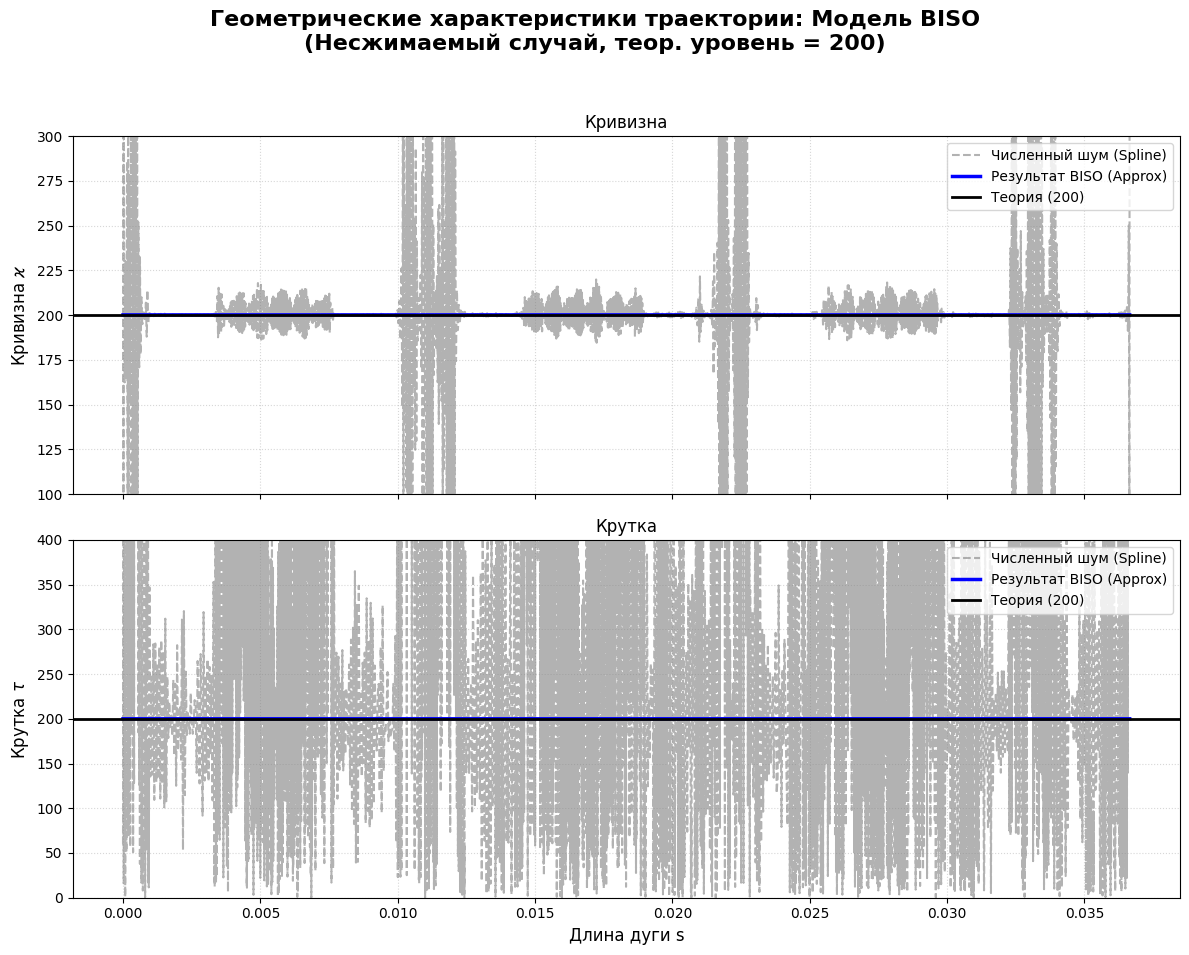

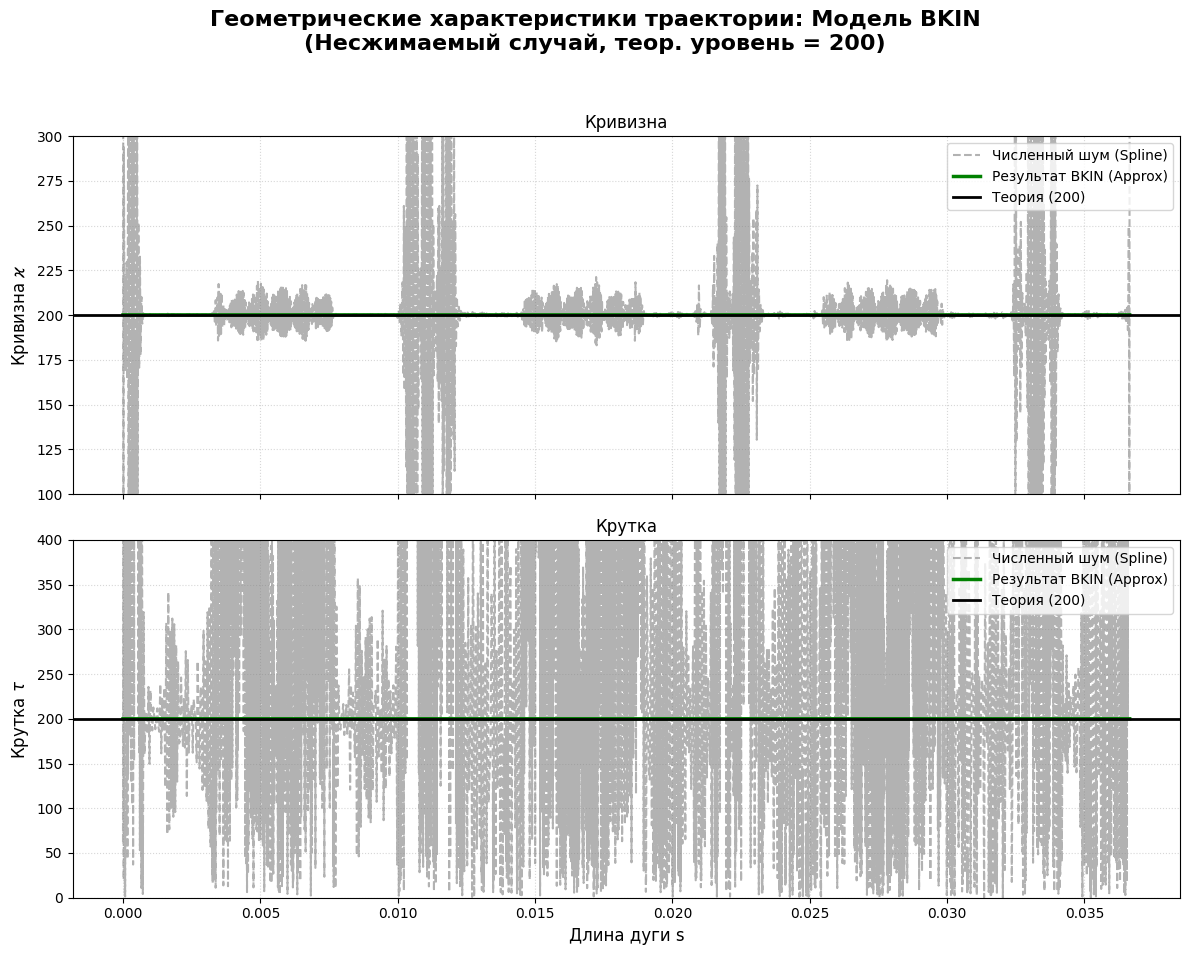

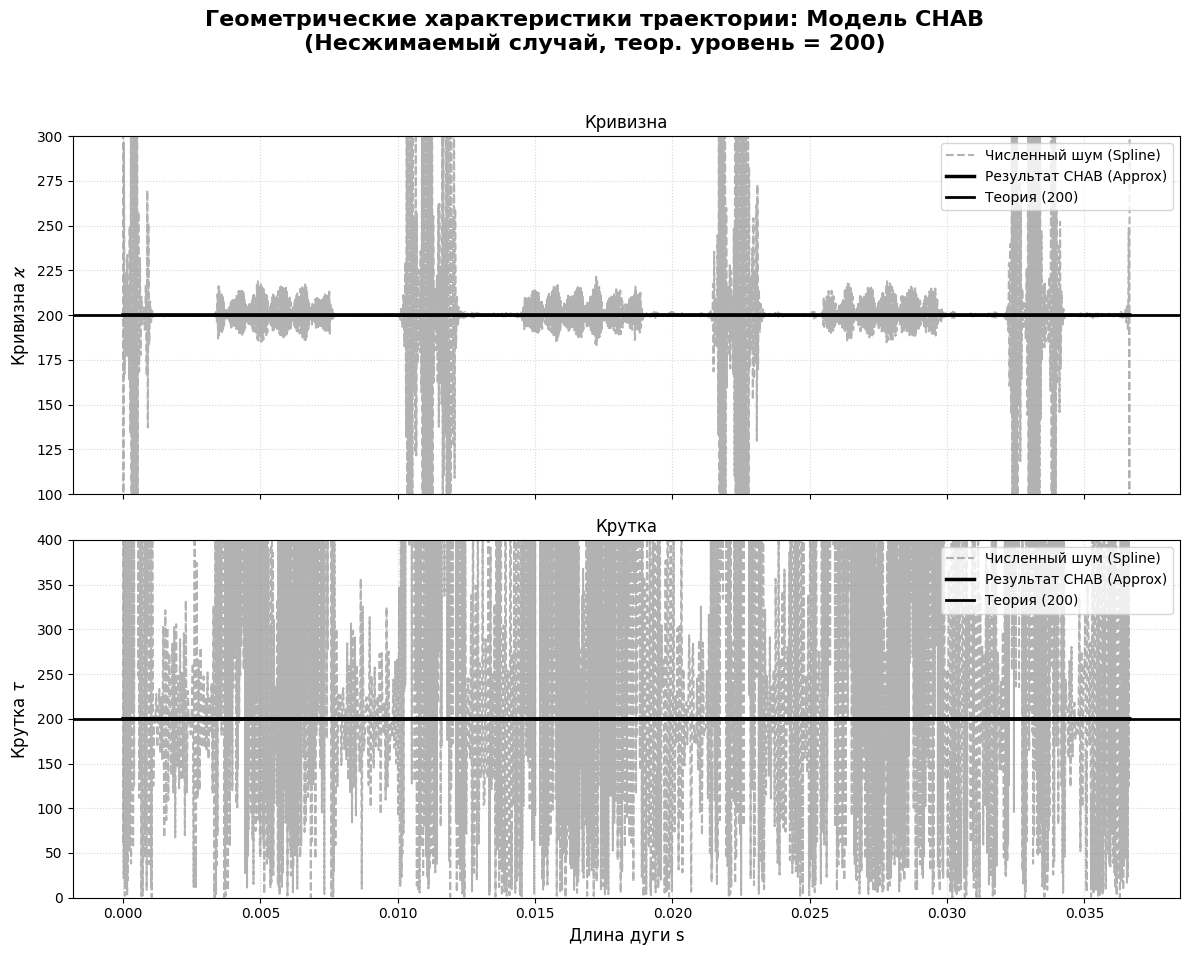

In [30]:
import matplotlib.pyplot as plt

colors = {'BISO': 'blue', 'BKIN': 'green', 'CHAB': 'black'}

for model in models:
    df = dfs[model]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f"Геометрические характеристики траектории: Модель {model}\n(Несжимаемый случай, теор. уровень = 200)", 
                 fontsize=16, fontweight='bold')

    ax1.plot(df['s'], df['kappa_spline'], color='gray', linestyle='--', alpha=0.6, label='Численный шум (Spline)')
    ax1.plot(df['s'], df['kappa_approx'], color=colors[model], linestyle='-', linewidth=2.5, label=f'Результат {model} (Approx)')
    ax1.axhline(200, color='black', linewidth=2, label='Теория (200)')
    
    ax1.set_ylabel("Кривизна $\\varkappa$", fontsize=12)
    ax1.set_ylim(100, 300)
    ax1.grid(True, which='both', linestyle=':', alpha=0.5)
    ax1.legend(loc='upper right')
    ax1.set_title("Кривизна")

    ax2.plot(df['s'], df['tau_spline'], color='gray', linestyle='--', alpha=0.6, label='Численный шум (Spline)')
    ax2.plot(df['s'], df['tau_approx'], color=colors[model], linestyle='-', linewidth=2.5, label=f'Результат {model} (Approx)')
    ax2.axhline(200, color='black', linewidth=2, label='Теория (200)')
    
    ax2.set_ylabel("Крутка $\\tau$", fontsize=12)
    ax2.set_xlabel("Длина дуги s", fontsize=12)
    ax2.set_ylim(0, 400)
    ax2.grid(True, which='both', linestyle=':', alpha=0.5)
    ax2.legend(loc='upper right')
    ax2.set_title("Крутка")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

<>:24: SyntaxWarning: invalid escape sequence '\S'
<>:24: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Arina\AppData\Local\Temp\ipykernel_38788\526130930.py:24: SyntaxWarning: invalid escape sequence '\S'
  ax1.set_title("Интенсивность напряжений $|\Sigma|$")


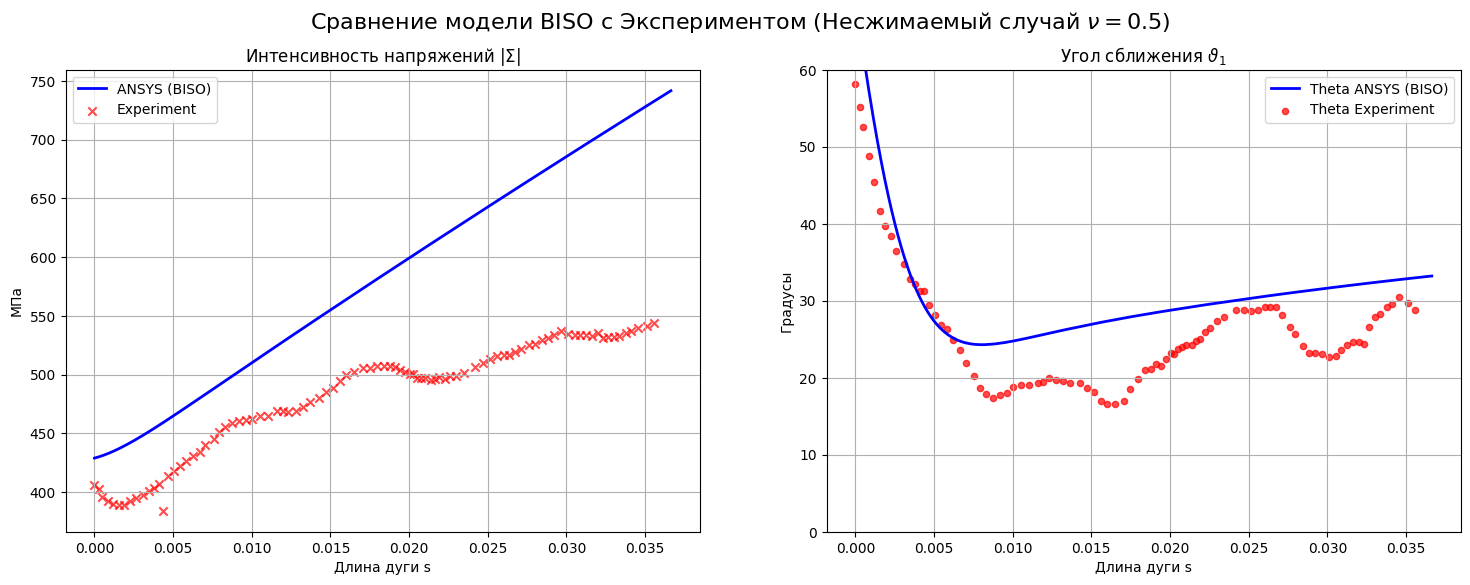

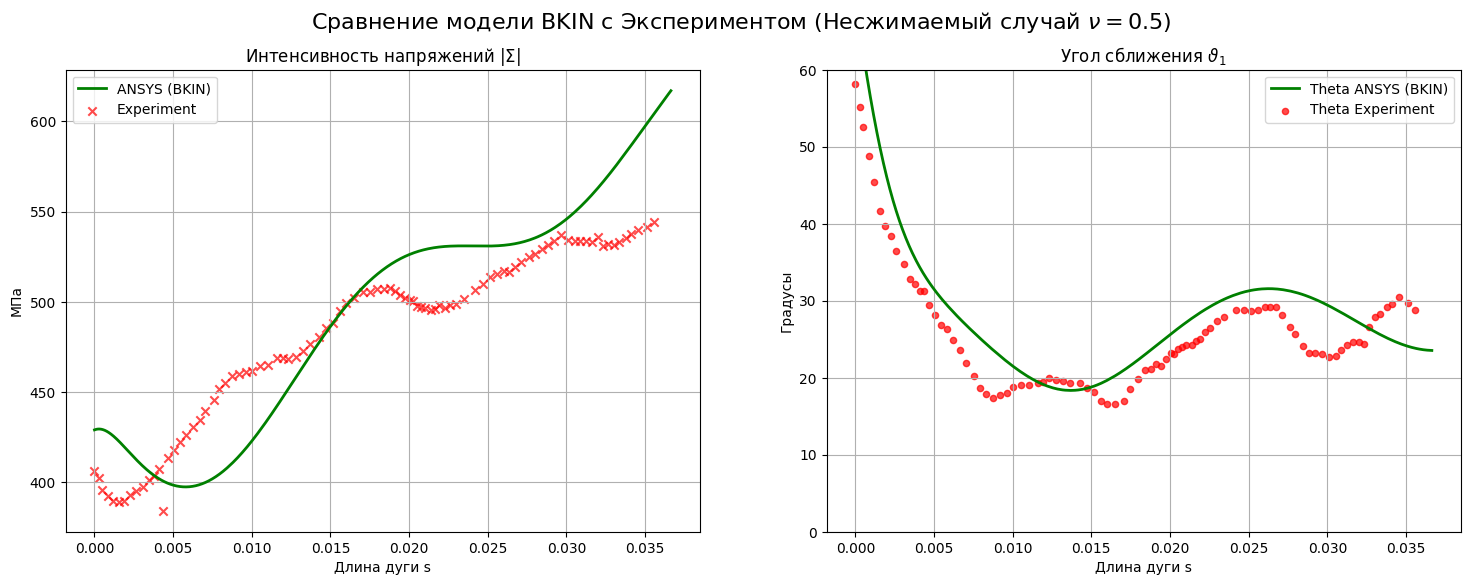

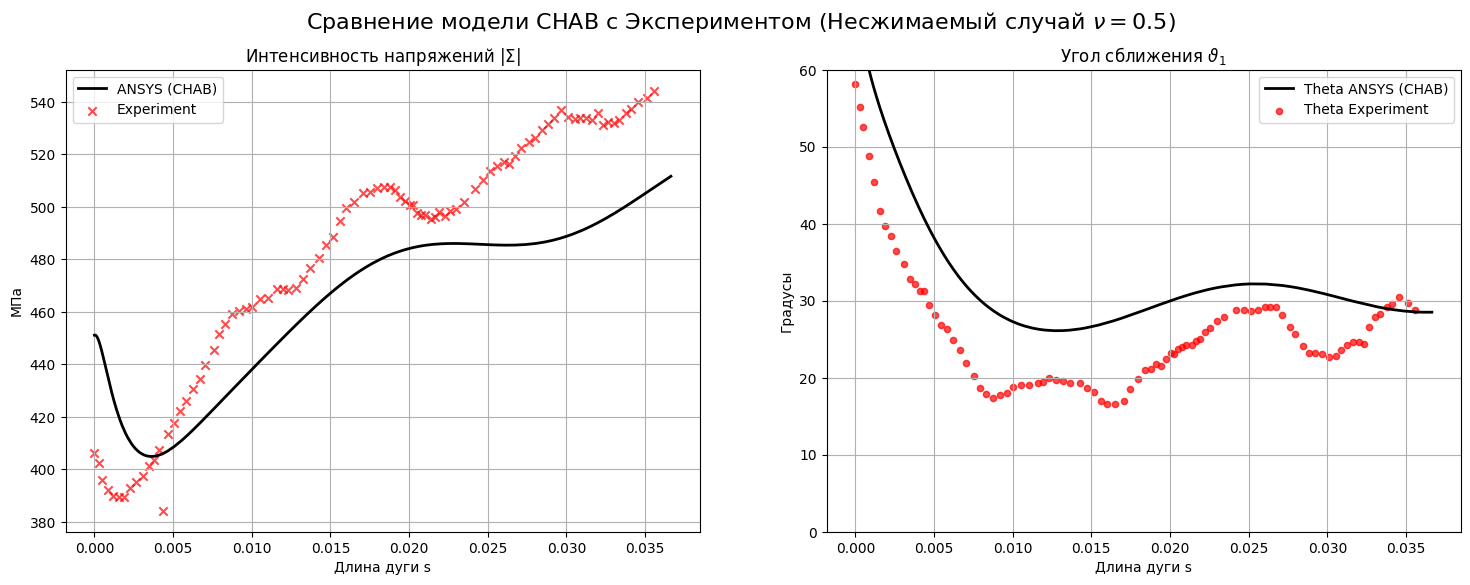

In [31]:
for model in models:
    df = dfs[model]

    df['S_EQV_mc'] = np.sqrt(df['Sig_1']**2 + df['Sig_2']**2 + df['Sig_3']**2)
    v_ans = approx_tool.get_derivatives(df['s'].values)
    df_theta_calc_ans = pd.DataFrame({
        'Sig_1': df['Sig_1'], 'Sig_2': df['Sig_2'], 'Sig_3': df['Sig_3'],
        'dEps_1_approx': v_ans[0], 'dEps_2_approx': v_ans[1], 'dEps_3_approx': v_ans[2]
    })
    df['Theta_Approx'] = calculate_theta(df_theta_calc_ans, deriv_suffix='_approx')

    v_ans_at_exp = approx_tool.get_derivatives(df_exp_vint['s_plot'].values)
    df_theta_calc_exp = pd.DataFrame({
        'Sig_1': df_exp_vint['Sig_1'], 'Sig_2': df_exp_vint['Sig_2'], 'Sig_3': df_exp_vint['Sig_3'],
        'dEps_1_approx': v_ans_at_exp[0], 'dEps_2_approx': v_ans_at_exp[1], 'dEps_3_approx': v_ans_at_exp[2]
    })
    df_exp_vint[f'Theta_vs_{model}'] = calculate_theta(df_theta_calc_exp, deriv_suffix='_approx')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f"Сравнение модели {model} с Экспериментом (Несжимаемый случай $\\nu=0.5$)", fontsize=16)

    ax1.plot(df['s'], df['S_EQV_mc'], color=colors[model], label=f'ANSYS ({model})', linewidth=2)
    ax1.scatter(df_exp_vint['s_plot'], df_exp_vint['S_EQV_exp'], color='red', marker='x', alpha=0.7, label='Experiment')
    ax1.set_title("Интенсивность напряжений $|\Sigma|$")
    ax1.set_xlabel("Длина дуги s")
    ax1.set_ylabel("МПа")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(df['s'], df['Theta_Approx'], color=colors[model], label=f'Theta ANSYS ({model})', linewidth=2)
    ax2.scatter(df_exp_vint['s_plot'], df_exp_vint[f'Theta_vs_{model}'], color='red', marker='o', s=20, alpha=0.7, label='Theta Experiment')
    ax2.set_title("Угол сближения $\\vartheta_1$")
    ax2.set_xlabel("Длина дуги s")
    ax2.set_ylabel("Градусы")
    ax2.set_ylim(0, 60)
    ax2.legend()
    ax2.grid(True)

    plt.show()

### Заключение по результатам верификации (несжимаемый случай)

На основе проведенного анализа трех моделей упрочнения (**BISO**, **BKIN**, **CHAB**) при коэффициенте Пуассона $\nu \to 0.5$ можно сделать следующие выводы:

1. **Неприменимость сплайн-аппроксимации:** 
   Численное дифференцирование с использованием стандартных сглаживающих сплайнов показало свою полную неэффективность для расчета геометрических характеристик высокого порядка (особенно крутки $\tau$). Даже при минимальном уровне численного шума в данных ANSYS, сплайны генерируют **катастрофическую погрешность**, выраженную в высокочастотных осцилляциях с амплитудой, на порядки превышающей теоретические значения. Это подтверждает невозможность использования локальных методов сглаживания для анализа сложных траекторий.

2. **Эффективность аппроксимации среднего напряжения:**
   Предложенный метод, основанный на глобальной гармонической аппроксимации среднего напряжения (`VolumetricModel`), показал **идеальное совпадение** с аналитическим решением. Для всех трех моделей упрочнения расчетные значения кривизны и крутки стабилизировались на теоретической отметке **200**. Метод успешно фильтрует численный дребезг решателя и восстанавливает истинную геометрию процесса, что делает его базовым инструментом для дальнейших исследований.

3. **Несоответствие гипотезы несжимаемости эксперименту:**
   Несмотря на математическую точность алгоритмов, результаты моделирования при $\nu = 0.5$ демонстрируют **плохую корреляцию с экспериментальными данными** 1986 года. 
   * Во-первых, наблюдается значительное расхождение по длине дуги $s$ (путь в модели оказывается короче реального).
   * Во-воторых, амплитуда и фаза углов сближения $\vartheta_1$ в эксперименте существенно отличаются от «идеальных» кривых.
   
Это свидетельствует о том, что для адекватного моделирования реальных процессов деформирования стали 45 **необходимо учитывать упругую сжимаемость материала** ($\nu \approx 0.29-0.3$). Переход к сжимаемому случаю позволит синхронизировать расчетную и экспериментальную длины траекторий и уточнить векторные свойства материала.